<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/computer_vision/gan_comparison_fashion/GAN_comparison_fashion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Работа с изображениями
from PIL import Image
import imageio
import cv2
from keras.preprocessing.image import img_to_array

# Библиотека линейной алгебры
import numpy as np

# Работа с файловой системой и системными функциями
import os

# Подготовка данных
from keras import preprocessing
import tensorflow as tf

# Построение сети
from keras.models import Sequential
from keras.layers import Conv2D,Dropout,Dense,Flatten,Conv2DTranspose,BatchNormalization,LeakyReLU,Reshape

# Визуализация выполнения процессов, циклов
from tqdm import tqdm

# Генерация случайных чисел
import re

# Работа с графиками
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Отключаем лишние предупреждения
import warnings
warnings.filterwarnings('ignore')

In [ ]:
SIZE = 28                   # линейный размер изображений (одно измерение)
INPUT_IMG = (SIZE, SIZE, 1) # размер входного изображений (MNIST Fashion - grayscale)
BATCH_SIZE = 256             # размер пакета для обучения
LATENT_DIM = 100            # размерность латентного пространства

In [ ]:
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train = np.concatenate([X_train, X_test], axis=0)

#X_train = X_test

X_train = X_train.reshape(X_train.shape[0], SIZE, SIZE, 1).astype('float32')
# Приводим к распределению от -1 до 1
X_train = (X_train - 127.5) / 127.5

dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(X_train.shape[0]).batch(BATCH_SIZE)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


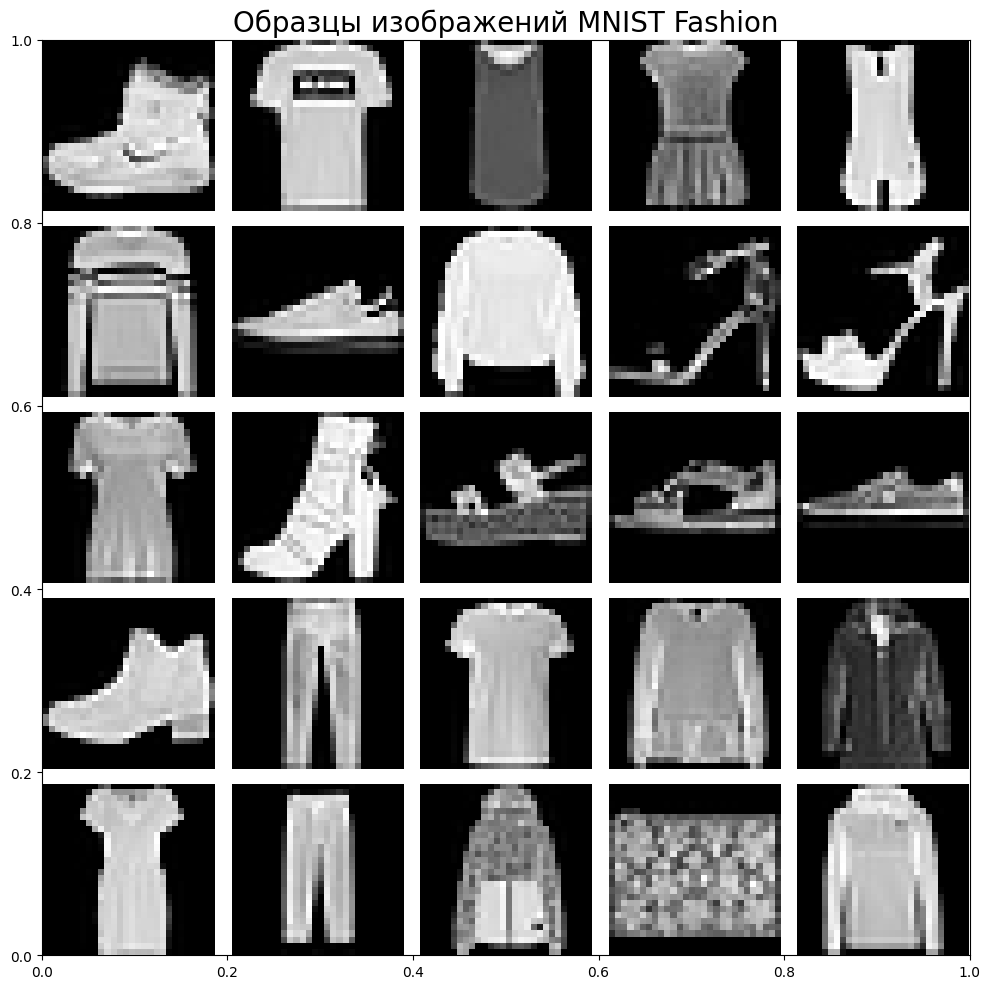

In [ ]:
def plot_images(images, title="Реальные изображения", num_display=25):
    plt.figure(figsize=(10,10))
    plt.title(title, fontsize=20)
    for i in range(num_display):
        plt.subplot(int(np.sqrt(num_display)), int(np.sqrt(num_display)), i+1)
        img_to_show = (images[i] * 0.5 + 0.5).squeeze()
        plt.imshow(img_to_show, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_images(X_train, title="Образцы изображений MNIST Fashion", num_display=25)

In [ ]:
def ClassicGenerator():
    model = Sequential()
    # Входной блок
    model.add(Dense(7*7*256, use_bias=False, input_shape=(LATENT_DIM,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(Reshape((7, 7, 256)))

    # Повышающие слои
    model.add(Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model

In [ ]:
def ImprovedGenerator():
    model = Sequential()
    # Входной блок
    model.add(Dense(7 * 7 * 256, use_bias=False, input_shape=(LATENT_DIM,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(Reshape((7, 7, 256)))

    # Повышающие слои
    model.add(Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2DTranspose(32, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')) # Upsample to 28x28, output 1 channel

    return model

In [ ]:
def ClassicDiscriminator():
    model = Sequential()
    model.add(Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=INPUT_IMG))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    model.add(Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

In [ ]:
def ImprovedDiscriminator():
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Input(INPUT_IMG))
    model.add(tf.keras.layers.Conv2D(SIZE,4, strides=2, padding='same',kernel_initializer='he_normal', use_bias=False))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Conv2D(SIZE,4, strides=2, padding='same',kernel_initializer='he_normal', use_bias=False))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Conv2D(SIZE*2,4, strides=2, padding='same',kernel_initializer='he_normal', use_bias=False))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Conv2D(SIZE*2,4, strides=2, padding='same',kernel_initializer='he_normal', use_bias=False))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Conv2D(SIZE*4,4, strides=2, padding='same',kernel_initializer='he_normal', use_bias=False))
    model.add(tf.keras.layers.LeakyReLU())
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(1,activation = 'sigmoid'))
    return model

In [ ]:
# Создание моделей для обоих GAN
imp_generator = ImprovedGenerator()
imp_discriminator = ImprovedDiscriminator()

classic_generator = ClassicGenerator()
classic_discriminator = ClassicDiscriminator()

print("Improved Generator Summary:")
imp_generator.summary()
print("\nImproved Discriminator Summary:")
imp_discriminator.summary()
print("\nClassic Generator Summary:")
classic_generator.summary()
print("\nClassic Discriminator Summary:")
classic_discriminator.summary()

Improved Generator Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │           800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,381,472 (9.08 MB)

 Trainable params: 2,355,936 (8.99 MB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

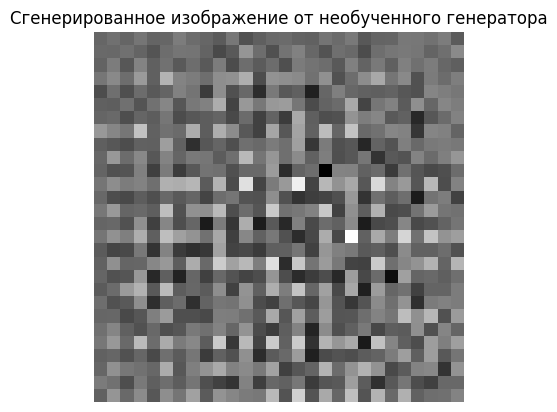

In [ ]:
noise = np.random.normal(-1,1,(1,LATENT_DIM))
img = imp_generator(noise, training=False)
plt.imshow(np.clip((img[0,...]+1)/2, 0, 1).squeeze(), cmap='gray')
plt.title('Сгенерированное изображение от необученного генератора')
plt.axis('off')
plt.show()

In [ ]:
# Оптимизаторы для улучшенного GAN
imp_optimizer_G = tf.keras.optimizers.RMSprop(learning_rate=.0001)
imp_optimizer_D = tf.keras.optimizers.RMSprop(learning_rate=.0001)

# Оптимизаторы для классического GAN
classic_optimizer_G = tf.keras.optimizers.RMSprop(learning_rate=.0001)
classic_optimizer_D = tf.keras.optimizers.RMSprop(learning_rate=.0001)

In [ ]:
# Этот метод возвращает вспомогательную функцию для вычисления перекрестных потерь энтропии
cross_entropy = tf.keras.losses.BinaryCrossentropy()

# На основе бинарной кросс-энтропии определим функцию потерь для дискриминатора.
def discriminator_loss(fake_output, real_output):
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    return fake_loss + real_loss

# Функция потерь генератора количественно определяет, насколько хорошо он смог обмануть дискриминатор.
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Мы используем декоратор `tf.function`, можно и без него
# Он указывает на то, что функция должна быть скомпилирована, что оптимизирует процесс обучения.
def train_steps_gan(generator_model, discriminator_model, optimizer_g, optimizer_d, images):

    # генерируем шум на входе генератора
    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))

    # Инициализируем GradientTape (градиентную ленту) для дискриминатора и генератор
    #  по отдельности, чтобы записать операции,
    # выполняемые во время прямого прохода, включающего автодифференцирование.
    with tf.GradientTape() as gen_tape , tf.GradientTape() as disc_tape:
        # Запустим прямой проход шума через генератор.
        # Операции применяемые каждым слоем к своим
        # входным данным будут записаны на GradientTape, как на ленту магнитофона.
        # Отсюда и название градиентной ленты.
        generated_images = generator_model(noise, training=True) # Pass training=True for BatchNormalization

        # Также обеспечиваем прямой проход через дискриминатор для
        # для реальных и фейковых изображений
        fake_output = discriminator_model(generated_images, training=True) # Pass training=True
        real_output = discriminator_model(images, training=True) # Pass training=True

        # расчитываем функции ошибок (значения потерь)
        gen_loss = generator_loss(fake_output)
        dis_loss = discriminator_loss(fake_output, real_output)

    # Используем gradient tape для автоматического извлечения градиентов
    # обучаемых переменных относительно потерь.
    gradient_of_generator = gen_tape.gradient(gen_loss, generator_model.trainable_variables)
    gradient_of_discriminator = disc_tape.gradient(dis_loss, discriminator_model.trainable_variables)

    # Выполним один шаг градиентного спуска, обновив
    # значение переменных минимизирующих потери.
    optimizer_g.apply_gradients(zip(gradient_of_generator, generator_model.trainable_variables))
    optimizer_d.apply_gradients(zip(gradient_of_discriminator, discriminator_model.trainable_variables))

    # Вернем значения потерь для визуализации
    loss = {'gen_loss':gen_loss,
           'disc_loss': dis_loss}
    return loss

In [ ]:
import time
def train_gan(epochs, dataset, generator_model, discriminator_model, optimizer_g, optimizer_d):
    D_loss=[] # список для сбора значений потерь для дискриминатора
    G_loss=[] # список для сбора значений потерь для генератора
    for epoch in range(epochs):
        start = time.time()
        print(f"\nЭпоха : {epoch + 1}")
        for images_batch in dataset:
            loss = train_steps_gan(generator_model, discriminator_model, optimizer_g, optimizer_d, images_batch)
        print(" Время:{}".format(np.round(time.time() - start),2))
        print(f"Generator Loss: {loss['gen_loss']} Discriminator Loss: {loss['disc_loss']}")
        D_loss.append(loss['disc_loss'])
        G_loss.append(loss['gen_loss'])
    return (G_loss, D_loss)

In [ ]:
EPOCHS = 20

print("\n*** Обучение Улучшенной GAN ***")
imp_G_loss, imp_D_loss = train_gan(EPOCHS, dataset, imp_generator, imp_discriminator, imp_optimizer_G, imp_optimizer_D)

print("\n*** Обучение Классической GAN ***")

# Создание фиктивных переменных для оптимизаторов
dummy_gen_vars = classic_generator.trainable_variables
if dummy_gen_vars:
    classic_optimizer_G.apply_gradients(zip([tf.zeros_like(v) for v in dummy_gen_vars], dummy_gen_vars))

dummy_disc_vars = classic_discriminator.trainable_variables
if dummy_disc_vars:
    classic_optimizer_D.apply_gradients(zip([tf.zeros_like(v) for v in dummy_disc_vars], dummy_disc_vars))

classic_G_loss, classic_D_loss = train_gan(EPOCHS, dataset, classic_generator, classic_discriminator, classic_optimizer_G, classic_optimizer_D)


*** Обучение Улучшенной GAN ***

Эпоха : 1
 Время:84.0
Generator Loss: 0.7155429720878601 Discriminator Loss: 1.332637071609497

Эпоха : 2
 Время:82.0
Generator Loss: 0.7435879111289978 Discriminator Loss: 1.33436918258667

Эпоха : 3
 Время:82.0
Generator Loss: 0.8025526404380798 Discriminator Loss: 1.2440361976623535

Эпоха : 4
 Время:81.0
Generator Loss: 0.8087495565414429 Discriminator Loss: 1.2646907567977905

Эпоха : 5
 Время:79.0
Generator Loss: 0.8652998208999634 Discriminator Loss: 1.1806652545928955

Эпоха : 6
 Время:79.0
Generator Loss: 0.8312733769416809 Discriminator Loss: 1.2752811908721924

Эпоха : 7
 Время:80.0
Generator Loss: 0.8543922901153564 Discriminator Loss: 1.2432113885879517

Эпоха : 8
 Время:80.0
Generator Loss: 0.8874714970588684 Discriminator Loss: 1.2744333744049072

Эпоха : 9
 Время:80.0
Generator Loss: 0.8302183151245117 Discriminator Loss: 1.2252211570739746

Эпоха : 10
 Время:79.0
Generator Loss: 0.7996097207069397 Discriminator Loss: 1.2770452499389648

In [ ]:
def plot_generated_images_single_gan(generator_model, title="Сгенерированные изображения", num_display=25):
  plt.figure(figsize = (10,10))
  plt.title(title, fontsize=20)
  for i in range(num_display):
    plt.subplot(int(np.sqrt(num_display)), int(np.sqrt(num_display)), i+1)
    noise = np.random.normal(0,1,(1,LATENT_DIM))
    img = generator_model(noise, training=False)
    plt.imshow(np.clip((img[0,...]+1)/2, 0, 1).squeeze(), cmap='gray')

    plt.axis('off')
    plt.grid(False)
  plt.tight_layout()
  plt.show()

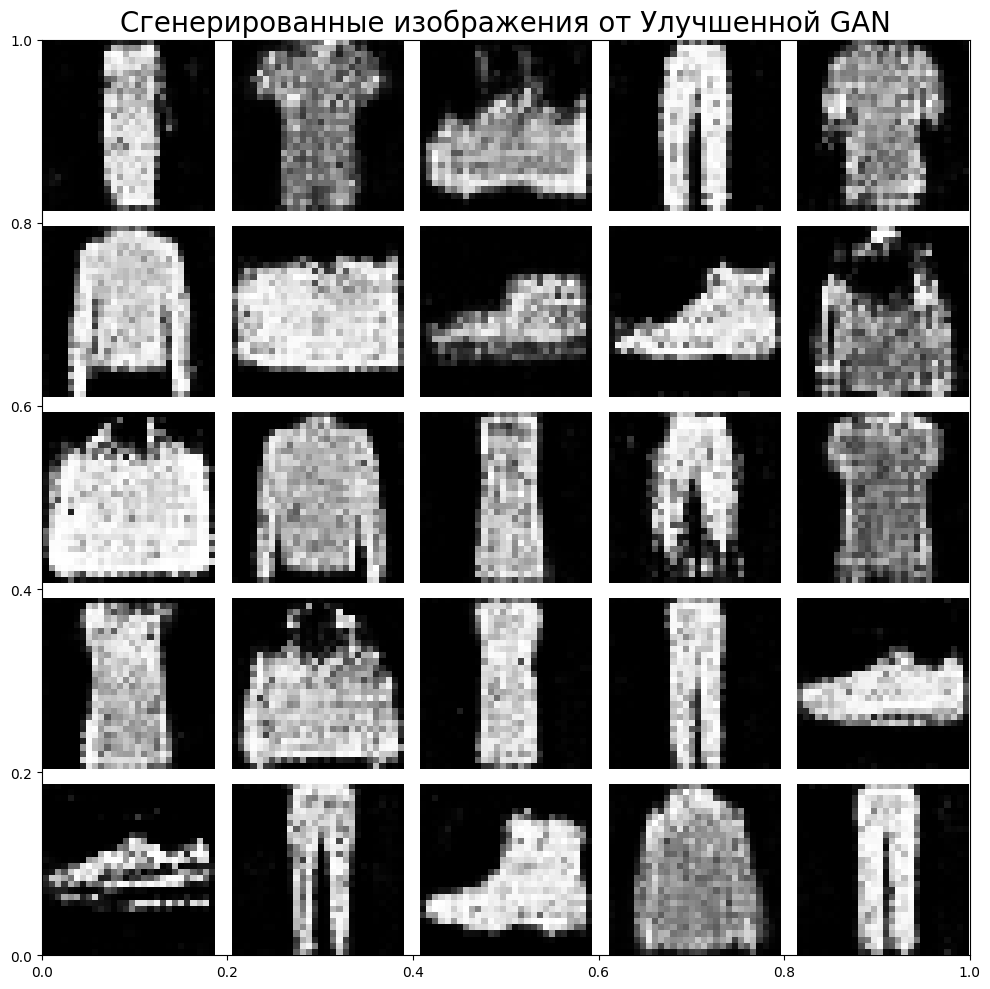

In [ ]:
plot_generated_images_single_gan(imp_generator, title="Сгенерированные изображения от Улучшенной GAN")

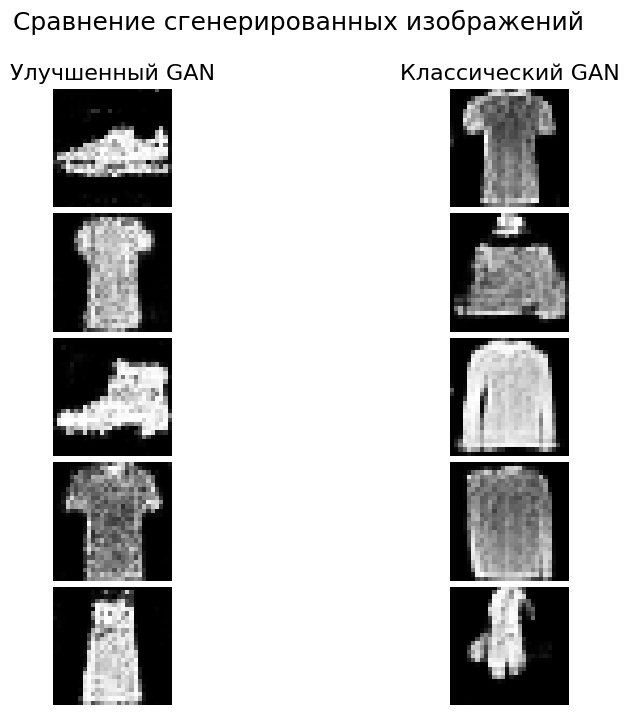

In [ ]:
# Заметим, что при равном количестве эпох для обоих генераторов качество получается примерно равное,
# и полученный результат даже похож на снимки одежды,
# но улучшенный GAN даёт большую резкость изображениям
def plot_comparison_images(imp_gen, classic_gen, num_display=5):
    plt.figure(figsize=(10, 8))

    noise = np.random.normal(0, 1, (num_display, LATENT_DIM))

    from matplotlib import gridspec
    gs = gridspec.GridSpec(num_display, 2, wspace=0.05, hspace=0.05)

    ax_imp_title = plt.subplot(gs[0, 0])
    ax_imp_title.text(0.5, 1.05, 'Улучшенный GAN', horizontalalignment='center', verticalalignment='bottom', transform=ax_imp_title.transAxes, fontsize=16)
    ax_imp_title.axis('off')
    for i in range(num_display):
        img = imp_gen(noise[i:i+1], training=False)
        ax = plt.subplot(gs[i, 0])
        ax.imshow(np.clip((img[0, ..., 0] + 1) / 2, 0, 1), cmap='gray')
        ax.axis('off')


    ax_classic_title = plt.subplot(gs[0, 1])
    ax_classic_title.text(0.5, 1.05, 'Классический GAN', horizontalalignment='center', verticalalignment='bottom', transform=ax_classic_title.transAxes, fontsize=16)
    ax_classic_title.axis('off')
    for i in range(num_display):
        img = classic_gen(noise[i:i+1], training=False)
        ax = plt.subplot(gs[i, 1])
        ax.imshow(np.clip((img[0, ..., 0] + 1) / 2, 0, 1), cmap='gray')
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle('Сравнение сгенерированных изображений', fontsize=18, y=0.98)
    plt.show()

plot_comparison_images(imp_generator, classic_generator, num_display=5)

In [ ]:
def loss_plot(G_loss_list, D_loss_list, title='Функции потерь в конце обучения на эпохе'):
    plt.figure(figsize=(10,10))
    plt.plot(G_loss_list,color='red',label='Функция потерь на генераторе')
    plt.plot(D_loss_list,color='blue',label='Функция потерь на дискриминаторе')
    plt.legend()
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.title(title)
    plt.show()

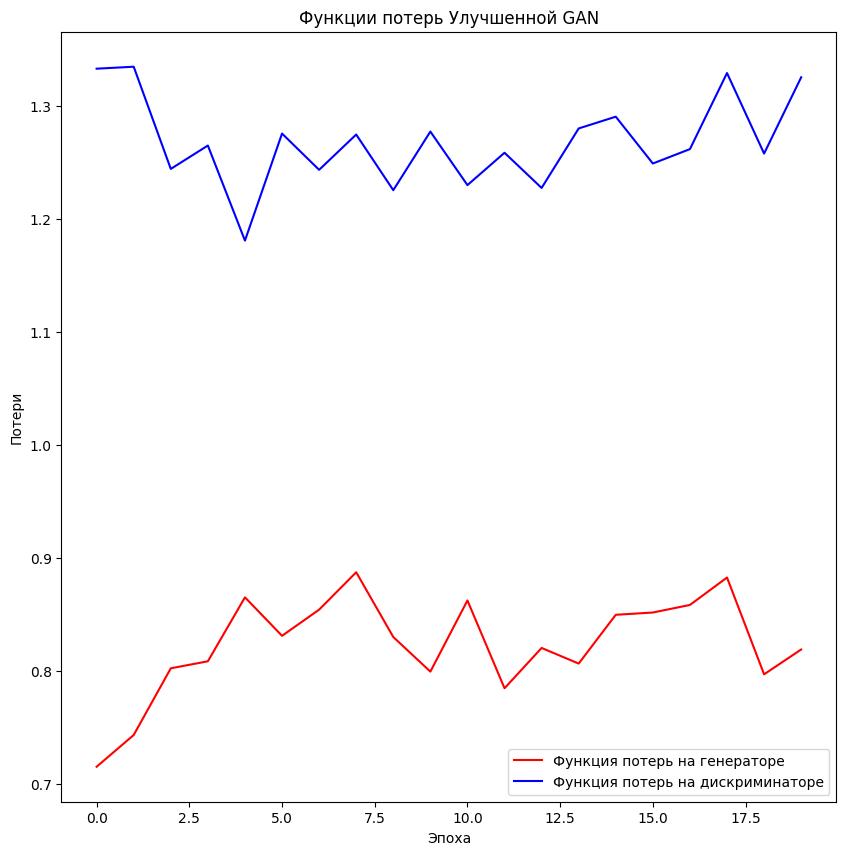

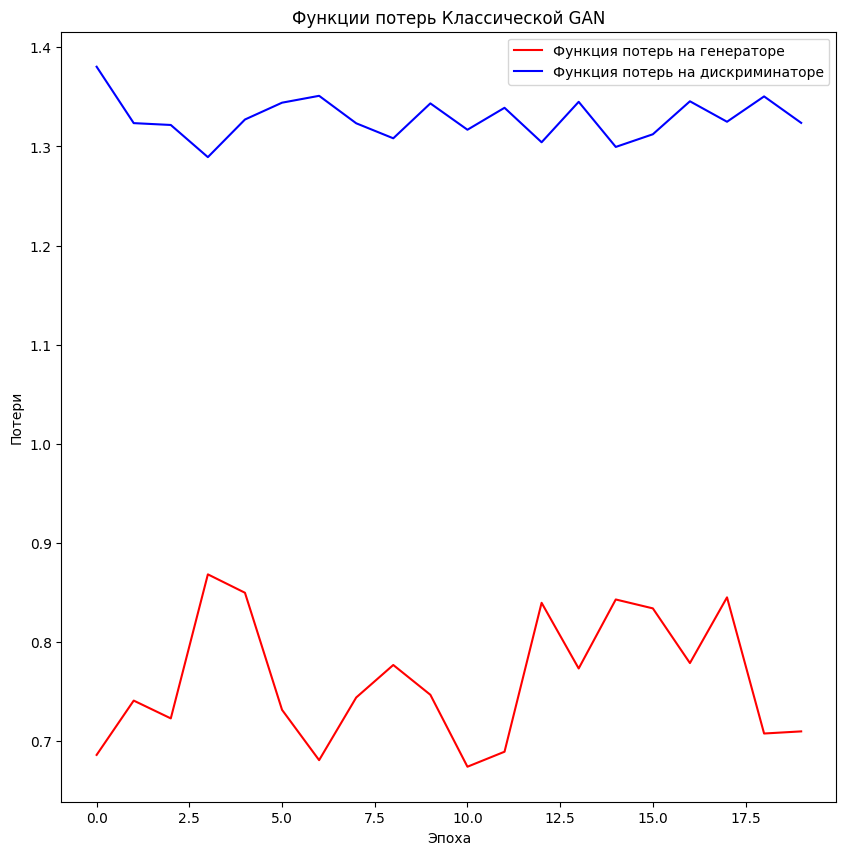

In [ ]:
loss_plot(imp_G_loss, imp_D_loss, title='Функции потерь Улучшенной GAN')
loss_plot(classic_G_loss, classic_D_loss, title='Функции потерь Классической GAN')